In [1]:
from enum import Enum
from typing import NamedTuple

class ChannelQuality(Enum):
    BAD = 0
    MEDIUM = 0.5
    HIGH = 1

class Channel(NamedTuple):
    channel_index: int
    channel_quality: ChannelQuality = None

class ActionType(Enum):
    STAY = 0
    SWITCH = 0.5

class Action(NamedTuple):
    type: ActionType
    channel_index: int

energy_consumption_weight = 0.5

env = [
    [
        Channel(0, ChannelQuality.MEDIUM),
        Channel(1, ChannelQuality.MEDIUM),
        Channel(2, ChannelQuality.MEDIUM),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.MEDIUM),
        Channel(5, ChannelQuality.MEDIUM),
        Channel(6, ChannelQuality.MEDIUM),
        Channel(7, ChannelQuality.MEDIUM),
    ],
    [
        Channel(0, ChannelQuality.MEDIUM),
        Channel(1, ChannelQuality.HIGH),
        Channel(2, ChannelQuality.BAD),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.HIGH),
        Channel(5, ChannelQuality.MEDIUM),
        Channel(6, ChannelQuality.MEDIUM),
        Channel(7, ChannelQuality.BAD),
    ],
    [
        Channel(0, ChannelQuality.BAD),
        Channel(1, ChannelQuality.MEDIUM),
        Channel(2, ChannelQuality.MEDIUM),
        Channel(3, ChannelQuality.HIGH),
        Channel(4, ChannelQuality.MEDIUM),
        Channel(5, ChannelQuality.HIGH),
        Channel(6, ChannelQuality.MEDIUM),
        Channel(7, ChannelQuality.MEDIUM),
    ],
    [
        Channel(0, ChannelQuality.HIGH),
        Channel(1, ChannelQuality.BAD),
        Channel(2, ChannelQuality.HIGH),
        Channel(3, ChannelQuality.BAD),
        Channel(4, ChannelQuality.HIGH),
        Channel(5, ChannelQuality.MEDIUM),
        Channel(6, ChannelQuality.BAD),
        Channel(7, ChannelQuality.MEDIUM),
    ],
    [
        Channel(0, ChannelQuality.MEDIUM),
        Channel(1, ChannelQuality.MEDIUM),
        Channel(2, ChannelQuality.BAD),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.MEDIUM),
        Channel(5, ChannelQuality.MEDIUM),
        Channel(6, ChannelQuality.MEDIUM),
        Channel(7, ChannelQuality.BAD),
    ],
    [
        Channel(0, ChannelQuality.MEDIUM),
        Channel(1, ChannelQuality.HIGH),
        Channel(2, ChannelQuality.MEDIUM),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.HIGH),
        Channel(5, ChannelQuality.BAD),
        Channel(6, ChannelQuality.MEDIUM),
        Channel(7, ChannelQuality.HIGH),
    ],
    [
        Channel(0, ChannelQuality.HIGH),
        Channel(1, ChannelQuality.MEDIUM),  
        Channel(2, ChannelQuality.BAD),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.MEDIUM),
        Channel(5, ChannelQuality.MEDIUM),
        Channel(6, ChannelQuality.HIGH),
        Channel(7, ChannelQuality.MEDIUM),
    ],
    [
        Channel(0, ChannelQuality.BAD),
        Channel(1, ChannelQuality.HIGH),
        Channel(2, ChannelQuality.MEDIUM),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.BAD),
        Channel(5, ChannelQuality.HIGH),
        Channel(6, ChannelQuality.BAD),
        Channel(7, ChannelQuality.BAD),
    ],
    [
        Channel(0, ChannelQuality.MEDIUM),
        Channel(1, ChannelQuality.BAD),
        Channel(2, ChannelQuality.MEDIUM),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.HIGH),
        Channel(5, ChannelQuality.BAD),
        Channel(6, ChannelQuality.MEDIUM),
        Channel(7, ChannelQuality.HIGH),
    ],
]

In [2]:
from itertools import product

class QTable(dict):
    def __init__(self, num_timestep, num_channels):

        super().__init__()
        self.num_timestep = num_timestep
        self.num_channels = num_channels
        self.channel_objects = [Channel(channel_index=i) for i in range(num_channels)]
        self.channel_map = {ch.channel_index: ch for ch in self.channel_objects}

        self._initialize_q_table()

    def _initialize_q_table(self):
        timesteps = list(range(self.num_timestep))
        states = list(product(timesteps, self.channel_objects))

        for state in states:
            _, current_channel = state
            actions = [Action(ActionType.SWITCH, channel_index=i)
                       for i in range(self.num_channels)
                       if i != current_channel.channel_index] + \
                      [Action(ActionType.STAY, channel_index=current_channel.channel_index)]

            self[state] = {action: 0.0 for action in actions}

    def _convert_key(self, key):
        if isinstance(key, tuple) and len(key) == 2:
            t, c = key
            if isinstance(c, int) and c in self.channel_map:
                return t, self.channel_map[c]
        return key

    def __getitem__(self, key):
        converted_key = self._convert_key(key)
        return super().__getitem__(converted_key)

    def __setitem__(self, key, value):
        converted_key = self._convert_key(key)
        return super().__setitem__(converted_key, value)

    def __contains__(self, key):
        converted_key = self._convert_key(key)
        return super().__contains__(converted_key)

    def get_all_actions_of_state(self, timestep, channel_index):
        return list(self[timestep, channel_index].keys())

    def set_q_value(self, timestep, channel_index, action, value):
        self[timestep, channel_index][action] = value

    def get_q_value(self, timestep, channel_index, action):
        return self[timestep, channel_index][action]

    def get_best_action(self, timestep, channel_index):
        state_actions = self[timestep, channel_index]
        return max(state_actions.keys(), key=lambda a: state_actions[a])

    def get_best_q_value(self, timestep, channel_index):
        return max(self[timestep, channel_index].values())

In [3]:
time_length = len(env)
num_channels = len(env[0])
q_table = QTable(time_length, num_channels)
# q_table[(0, Channel(0))] # (timestep: 0, channel: 0)
# q_table[(0, 0)] # same as above

In [4]:
from tqdm import tqdm
import random
import copy


# policy
def select_action(timestep:int, current_channel_index:int, epsilon:float=0.1):
    random_float = random.random()
    if random_float <= epsilon:
        is_random = True
        action = random.choice(q_table.get_all_actions_of_state(timestep, current_channel_index))
    else:
        action = q_table.get_best_action(timestep, current_channel_index)
        is_random = False
    # print(f"action: {action}")
    return action, is_random

def calculate_reward(action: Action, next_channel: Channel):
    return next_channel.channel_quality.value - energy_consumption_weight * action.type.value

def step(timestep: int, current_channel: Channel, action: Action):
    next_channel = current_channel
    for channel in env[timestep]:
        if channel.channel_index == action.channel_index:
            next_channel = channel
    return next_channel, calculate_reward(action, next_channel)

def run_q_learning(num_episodes:int,
                   q_table:QTable,
                   gamma:float,
                   initial_epsilon:float,
                   min_epsilon:float,
                   epsilon_decay:float,
                   initial_learning_rate:float,
                   min_learning_rate:float,
                   learning_rate_decay:float,
                   checkpoints:list[int]):
    q_history = []
    delta_q = dict()
    max_timestep = len(env) - 1
    episode_rewards = []

    for i in tqdm(range(num_episodes)):
        rewards = 0
        current_channel = Channel(7)
        epsilon = max(min_epsilon, initial_epsilon * (epsilon_decay ** i))
        learning_rate = max(min_learning_rate, initial_learning_rate * (learning_rate_decay ** i))

        for timestep in range(len(env)):
            chosen_action, is_random = select_action(timestep, current_channel.channel_index, epsilon=epsilon)
            if is_random:
                print(f"Random action selected at timestep {timestep}, episode {i}")

            next_channel, reward = step(timestep, current_channel, chosen_action)
            rewards += reward

            old_q = q_table.get_q_value(timestep=timestep,
                                       channel_index=current_channel.channel_index,
                                       action=chosen_action)
            
            if timestep == max_timestep:
                next_state_best_q = 0
            else:
                next_timestep = timestep + 1
                next_state_best_q = q_table.get_best_q_value(next_timestep, next_channel.channel_index)
            
            new_q = old_q + learning_rate * (reward + gamma * next_state_best_q - old_q)
            q_table.set_q_value(timestep, current_channel.channel_index, chosen_action, new_q)

            if (timestep, current_channel, chosen_action) not in delta_q:
                delta_q[(timestep, current_channel, chosen_action)] = []
            delta_q[(timestep, current_channel, chosen_action)].append(abs(new_q - old_q))
            current_channel = next_channel

        episode_rewards.append(rewards)

        if i in checkpoints:
            q_history.append(copy.deepcopy(q_table))
    
    print(f"Latest epsilon: {epsilon}")
    print(f"Latest learning rate: {learning_rate}")

    return q_history, delta_q, episode_rewards

In [6]:
initial_epsilon = 0.5
min_epsilon = 0.01
epsilon_decay = 0.997

initial_learning_rate = 0.1
min_learning_rate = 0.01
learning_rate_decay = 0.99

gamma = 0.99
num_episodes = 300
checkpoints = [int(num_episodes * 0.25), int(num_episodes * 0.5), num_episodes - 1]

q_history, delta_q, episode_rewards = run_q_learning(num_episodes, q_table,
                                    gamma,
                                    initial_epsilon, min_epsilon, epsilon_decay,
                                    initial_learning_rate, min_learning_rate, learning_rate_decay,
                                    checkpoints)

100%|██████████| 300/300 [00:00<00:00, 15297.63it/s]

Random action selected at timestep 0, episode 0
Random action selected at timestep 1, episode 0
Random action selected at timestep 3, episode 0
Random action selected at timestep 4, episode 0
Random action selected at timestep 5, episode 0
Random action selected at timestep 8, episode 0
Random action selected at timestep 0, episode 1
Random action selected at timestep 1, episode 1
Random action selected at timestep 3, episode 1
Random action selected at timestep 5, episode 1
Random action selected at timestep 7, episode 1
Random action selected at timestep 2, episode 2
Random action selected at timestep 6, episode 2
Random action selected at timestep 7, episode 2
Random action selected at timestep 1, episode 3
Random action selected at timestep 2, episode 3
Random action selected at timestep 5, episode 3
Random action selected at timestep 8, episode 3
Random action selected at timestep 0, episode 4
Random action selected at timestep 3, episode 4
Random action selected at timestep 4, ep

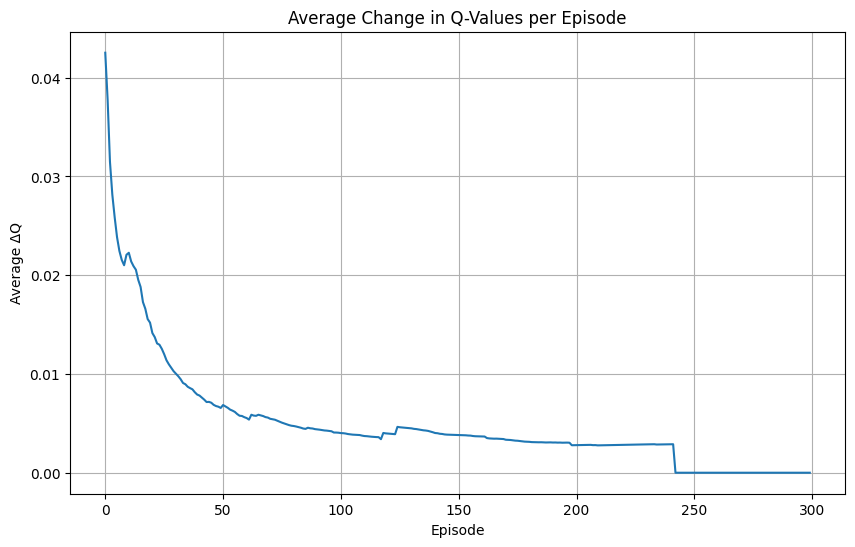

In [7]:
average_delta_per_episode = []
for i in range(num_episodes):
    episode_deltas = [delta_q[(t, c, a)][i] for (t, c, a) in delta_q.keys() if i < len(delta_q[(t, c, a)])]
    if episode_deltas:
        average_delta_per_episode.append(sum(episode_deltas) / len(episode_deltas))
    else:
        average_delta_per_episode.append(0)
    
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(average_delta_per_episode)
plt.title('Average Change in Q-Values per Episode')
plt.xlabel('Episode')
plt.ylabel('Average ΔQ')
plt.grid(True)
plt.show()

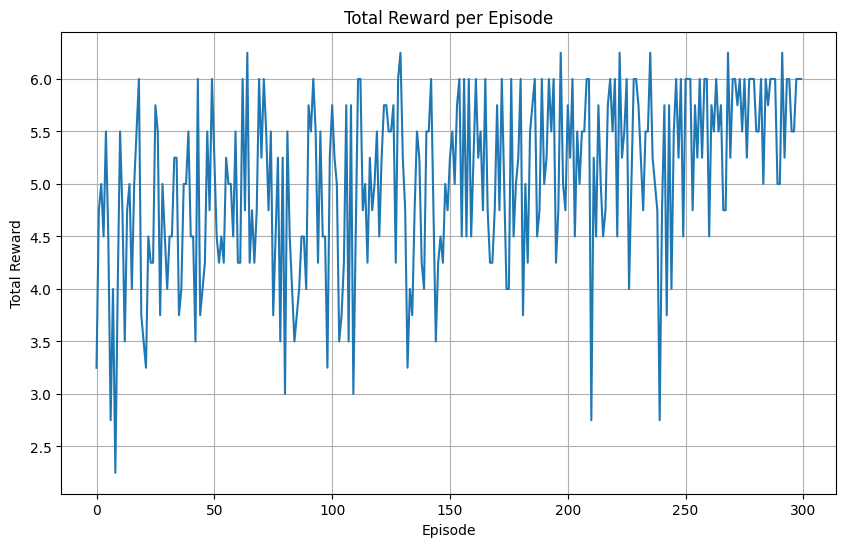

In [8]:
# Plot the rewards
plt.figure(figsize=(10, 6))
plt.plot(episode_rewards)
plt.title('Total Reward per Episode')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)
plt.show()